# Customer Churn Prediction — Phase 1: Exploratory Data Analysis

**Author:** Gabriel Effangha  
**Date:** April 2026  
**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 features)

---

**Goal of this notebook:**  
Understand the data before building any models. Specifically:
1. Inspect the structure, types, and quality of every column
2. Identify and handle data quality issues
3. Explore the target variable (Churn) and understand class imbalance
4. Visualise how each feature relates to churn
5. Examine correlations and spot the strongest predictive signals

Every chart and observation here will directly inform the preprocessing and modelling decisions in Phases 2 and 3.

## 1. Setup and Data Loading

We start by importing the libraries we need and loading the dataset. Pandas handles the tabular data, Matplotlib and Seaborn handle the visuals, and NumPy is there for numerical operations.

I'm also setting a consistent visual style with `sns.set_theme()` so all charts look clean and uniform throughout the notebook.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# Matplotlib defaults for consistent, readable charts
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [22]:
# Load the dataset
# The CSV lives in the data/ folder at the root of our repo
df = pd.read_csv('../data/telco_customer_churn.csv')

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")

Dataset shape: 7,043 rows × 21 columns

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## 2. First Look at the Data

Before doing anything clever, I need to know the basics: what does each row look like, what types are the columns, and are there any obvious issues? This is the "open the hood and look inside" step.

In [23]:
# Preview the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
# Data types and non-null counts for every column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [25]:
# Quick statistical summary of the numeric columns
df.describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


### Observations from the first look

A few things jump out immediately:

1. **TotalCharges is a string**, not a number. Pandas read it as `object` type, which means there are non-numeric values hiding in that column. We need to investigate and fix this.

2. **SeniorCitizen is already encoded as 0/1** while every other categorical column is in string format (Yes/No, Month-to-month, etc.). This is fine, but worth noting for consistency during preprocessing.

3. **customerID is just an identifier** — it has no predictive value and will be dropped before modelling.

4. **No null values appear** in the `.info()` output, but that does not mean the data is clean — the TotalCharges issue proves that. Hidden problems can look like valid data.

## 3. Data Quality Investigation

### 3.1 The TotalCharges Problem

TotalCharges should be a float, but Pandas read it as a string. Let's find out why by trying to convert it and seeing what fails.

In [26]:
# Try converting TotalCharges to numeric — coerce errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Find the rows that failed conversion
missing_tc = df[df['TotalCharges'].isna()]
print(f"Found {len(missing_tc)} rows where TotalCharges could not be converted.\n")
print(missing_tc[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

Found 11 rows where TotalCharges could not be converted.

      customerID  tenure  MonthlyCharges  TotalCharges Churn
488   4472-LVYGI       0           52.55           NaN    No
753   3115-CZMZD       0           20.25           NaN    No
936   5709-LVOEQ       0           80.85           NaN    No
1082  4367-NUYAO       0           25.75           NaN    No
1340  1371-DWPAZ       0           56.05           NaN    No
3331  7644-OMVMY       0           19.85           NaN    No
3826  3213-VVOLG       0           25.35           NaN    No
4380  2520-SGTTA       0           20.00           NaN    No
5218  2923-ARZLG       0           19.70           NaN    No
6670  4075-WKNIU       0           73.35           NaN    No
6754  2775-SEFEE       0           61.90           NaN    No


**What happened here:**  
All 11 problematic rows have `tenure = 0`. These are brand-new customers who have not been billed yet, so their TotalCharges field was left as a blank space (`" "`) in the original CSV. That blank space prevented Pandas from reading the column as a number.

**Decision:** Since these customers have zero tenure, their total charges should logically be 0. I will fill the NaN values with 0. This is not a guess — it is the only value that makes sense given the context.

In [27]:
# Fill the 11 missing TotalCharges with 0 (brand-new customers)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify the fix
print(f"Remaining NaNs in TotalCharges: {df['TotalCharges'].isna().sum()}")
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")

Remaining NaNs in TotalCharges: 0
TotalCharges dtype: float64


### 3.2 Duplicate Check

In [28]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Also check for duplicate customer IDs
duplicate_ids = df['customerID'].duplicated().sum()
print(f"Duplicate customer IDs: {duplicate_ids}")

Duplicate rows: 0
Duplicate customer IDs: 0


No duplicates — each row is a unique customer. The dataset is clean in that regard.

### 3.3 Column Types Summary

In [29]:
# Separate columns by type for the rest of the analysis
cat_cols = df.select_dtypes(include='object').columns.drop('customerID').tolist()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print(f"Categorical columns ({len(cat_cols)}):")
for col in cat_cols:
    unique_vals = df[col].unique()
    print(f"  {col}: {unique_vals}")

print(f"\nNumerical columns ({len(num_cols)}):")
for col in num_cols:
    print(f"  {col}: min={df[col].min()}, max={df[col].max()}, mean={df[col].mean():.2f}")

Categorical columns (16):
  gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
  Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
  Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
  PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
  MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
  InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
  OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
  OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
  DeviceProtection: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
  TechSupport: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
  StreamingTV: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
  StreamingMovies: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
  Cont

## 4. Target Variable: Churn Distribution

This is the most important chart in the entire notebook. Before I do anything else, I need to know how balanced or imbalanced the classes are. This single fact will influence my choice of evaluation metrics, whether I need resampling, and how I interpret model performance later.

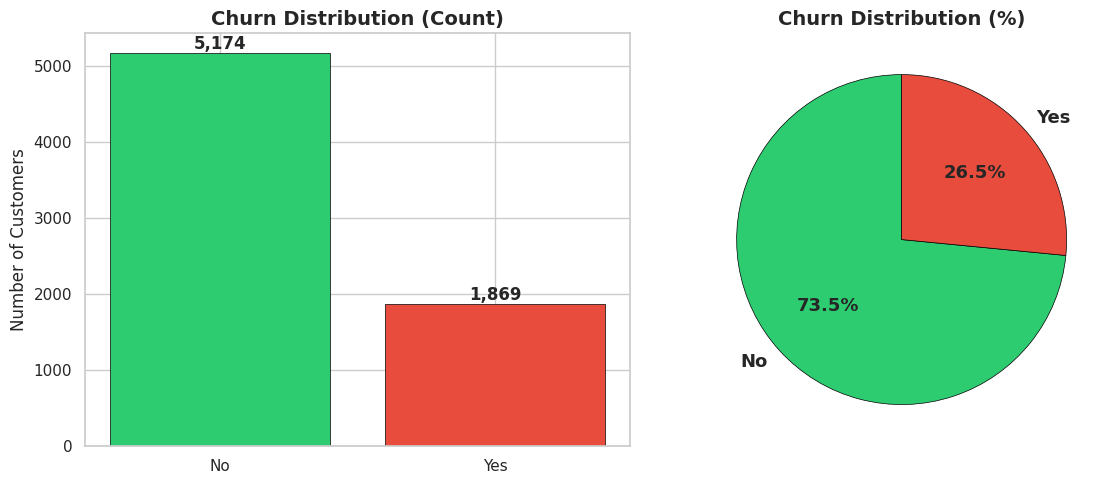


Churn rate: 26.5%
Non-churn rate: 73.5%
Imbalance ratio: 2.8 : 1


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Churn Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, (label, val) in enumerate(zip(churn_counts.index, churn_counts.values)):
    axes[0].text(i, val + 50, f'{val:,}', ha='center', fontweight='bold', fontsize=12)

# Percentage plot
churn_pct = df['Churn'].value_counts(normalize=True) * 100
axes[1].pie(churn_pct.values, labels=churn_pct.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 13, 'fontweight': 'bold'},
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
axes[1].set_title('Churn Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/figures/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChurn rate: {churn_pct['Yes']:.1f}%")
print(f"Non-churn rate: {churn_pct['No']:.1f}%")
print(f"Imbalance ratio: {churn_counts['No'] / churn_counts['Yes']:.1f} : 1")

### Key Takeaway: Class Imbalance

**26.5% of customers churned, 73.5% did not.** That is roughly a 2.8:1 imbalance.

This is significant because:
- A dummy model that always predicts "No Churn" would score 73.5% accuracy — and catch zero actual churners
- **Accuracy is therefore a misleading metric** for this problem
- I will rely on **F1 Score and ROC-AUC** instead, which account for both precision and recall
- During modelling, I may also experiment with class weights or resampling to help the model learn the minority class better

## 5. Numerical Feature Analysis

We have three numerical features: `tenure`, `MonthlyCharges`, and `TotalCharges`. Let's understand their distributions and how they relate to churn.

### 5.1 Distributions

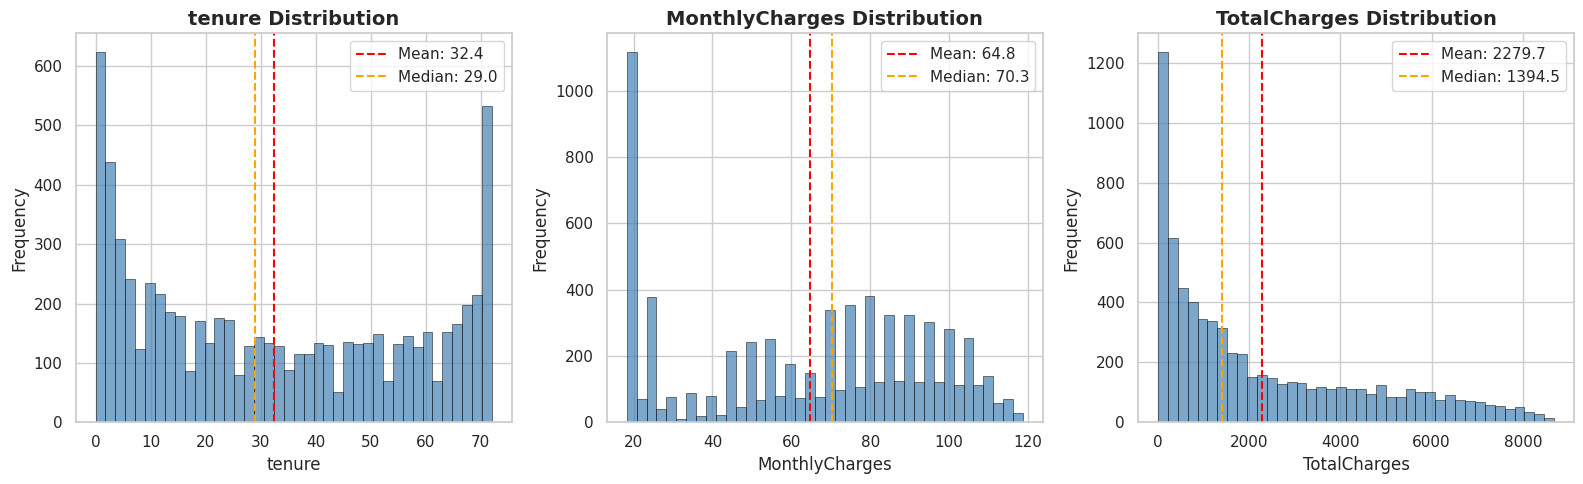

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='black', linewidth=0.5, alpha=0.7)
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[i].legend()

plt.tight_layout()
plt.savefig('../notebooks/figures/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**
- **Tenure** is almost bimodal — there is a spike of very new customers (0–5 months) and a cluster of very loyal customers (65–72 months). Customers tend to either leave early or stay for a long time.
- **MonthlyCharges** has a right-skewed shape with a concentration of customers paying around 20 (likely basic plans) and a spread up to about 120.
- **TotalCharges** is heavily right-skewed, which makes sense since it is roughly `tenure × MonthlyCharges`. The spike at 0 is from those 11 new customers we fixed earlier.

### 5.2 Numerical Features vs Churn

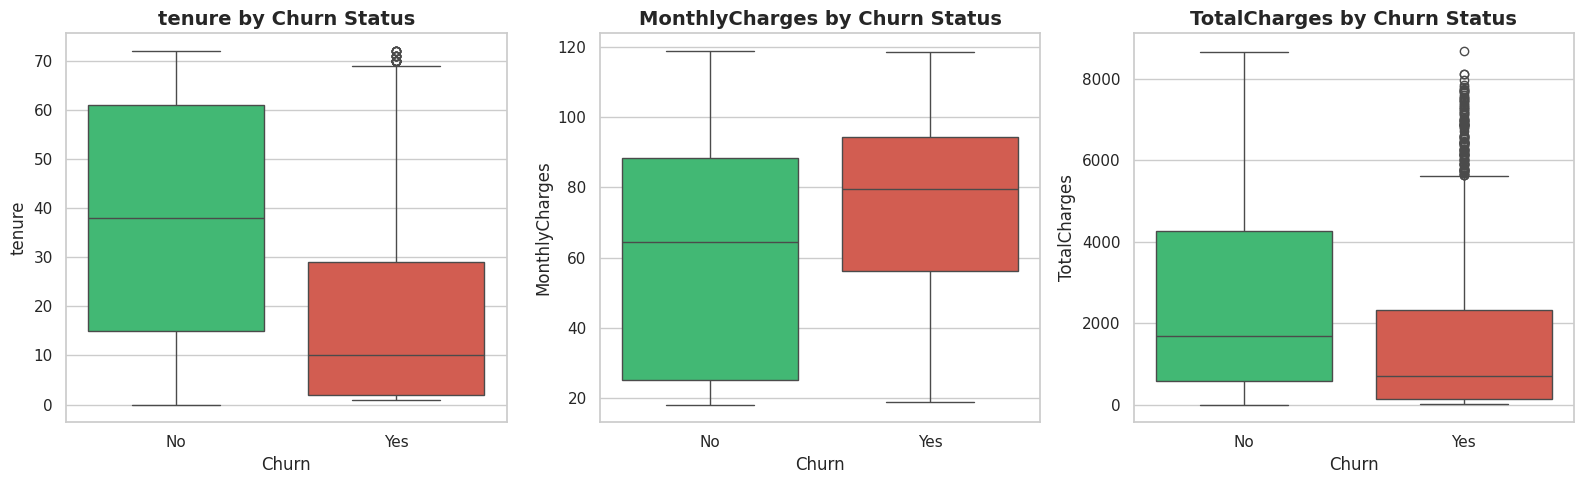

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
    axes[i].set_title(f'{col} by Churn Status', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/figures/numerical_vs_churn_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Print the exact medians for comparison
print("Median values by churn status:\n")
print(df.groupby('Churn')[num_cols].median().round(2).to_string())

Median values by churn status:

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0           64.43       1679.52
Yes      10.0           79.65        703.55


**Key Findings:**

1. **Tenure is the strongest numerical signal.** Customers who churn have a median tenure of ~10 months, while loyal customers have a median of ~38 months. Short-tenure customers are far more likely to leave.

2. **MonthlyCharges: churners pay more.** The median monthly charge for churners (~80) is noticeably higher than for non-churners (~64). This might indicate that higher-cost plans (likely fiber optic) have higher churn.

3. **TotalCharges: churners have paid less overall.** This makes sense — they leave earlier, so they accumulate less total spend. This feature is partly redundant with tenure.

## 6. Categorical Feature Analysis

Now let's look at how each categorical feature relates to churn. This is where the business insights really start to emerge.

### 6.1 Demographics: Gender, SeniorCitizen, Partner, Dependents

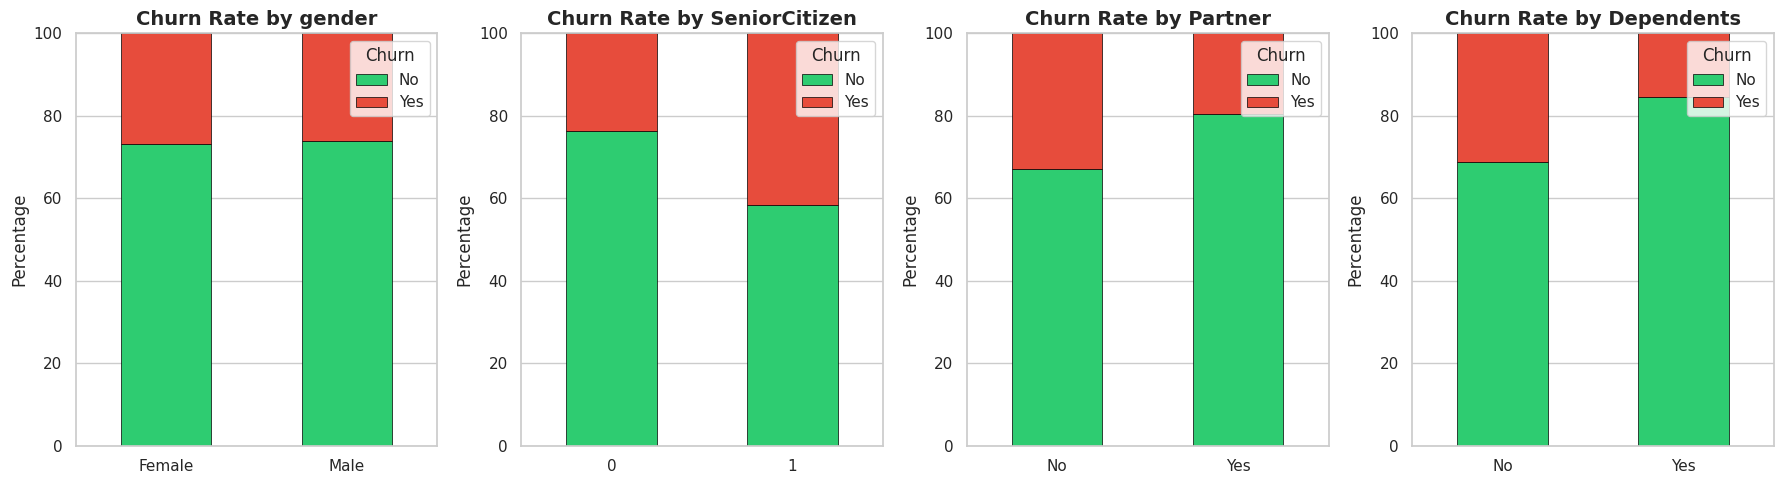

In [34]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(demo_cols):
    # Cross-tabulate with churn and get percentages
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Percentage')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].legend(title='Churn', loc='upper right')
    axes[i].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../notebooks/figures/demographics_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Exact churn rates by demographic
for col in demo_cols:
    print(f"\n--- {col} ---")
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
    print(churn_rate.to_string())


--- gender ---
gender
Female    26.9
Male      26.2

--- SeniorCitizen ---
SeniorCitizen
0    23.6
1    41.7

--- Partner ---
Partner
No     33.0
Yes    19.7

--- Dependents ---
Dependents
No     31.3
Yes    15.5


**Observations:**
- **Gender has almost no effect** on churn (~27% for both). It is unlikely to be a useful predictor.
- **Senior citizens churn at ~42%**, nearly double the ~24% rate for non-seniors. This is a strong signal.
- **Customers without partners churn more** (~33%) compared to those with partners (~20%).
- **Customers without dependents churn more** (~31%) compared to those with dependents (~15%). 

People with partners and dependents likely have bundled family plans or simply less motivation to switch — changing a plan that serves a whole household is more friction than changing a personal one.

### 6.2 Service Features: Internet, Phone, and Add-ons

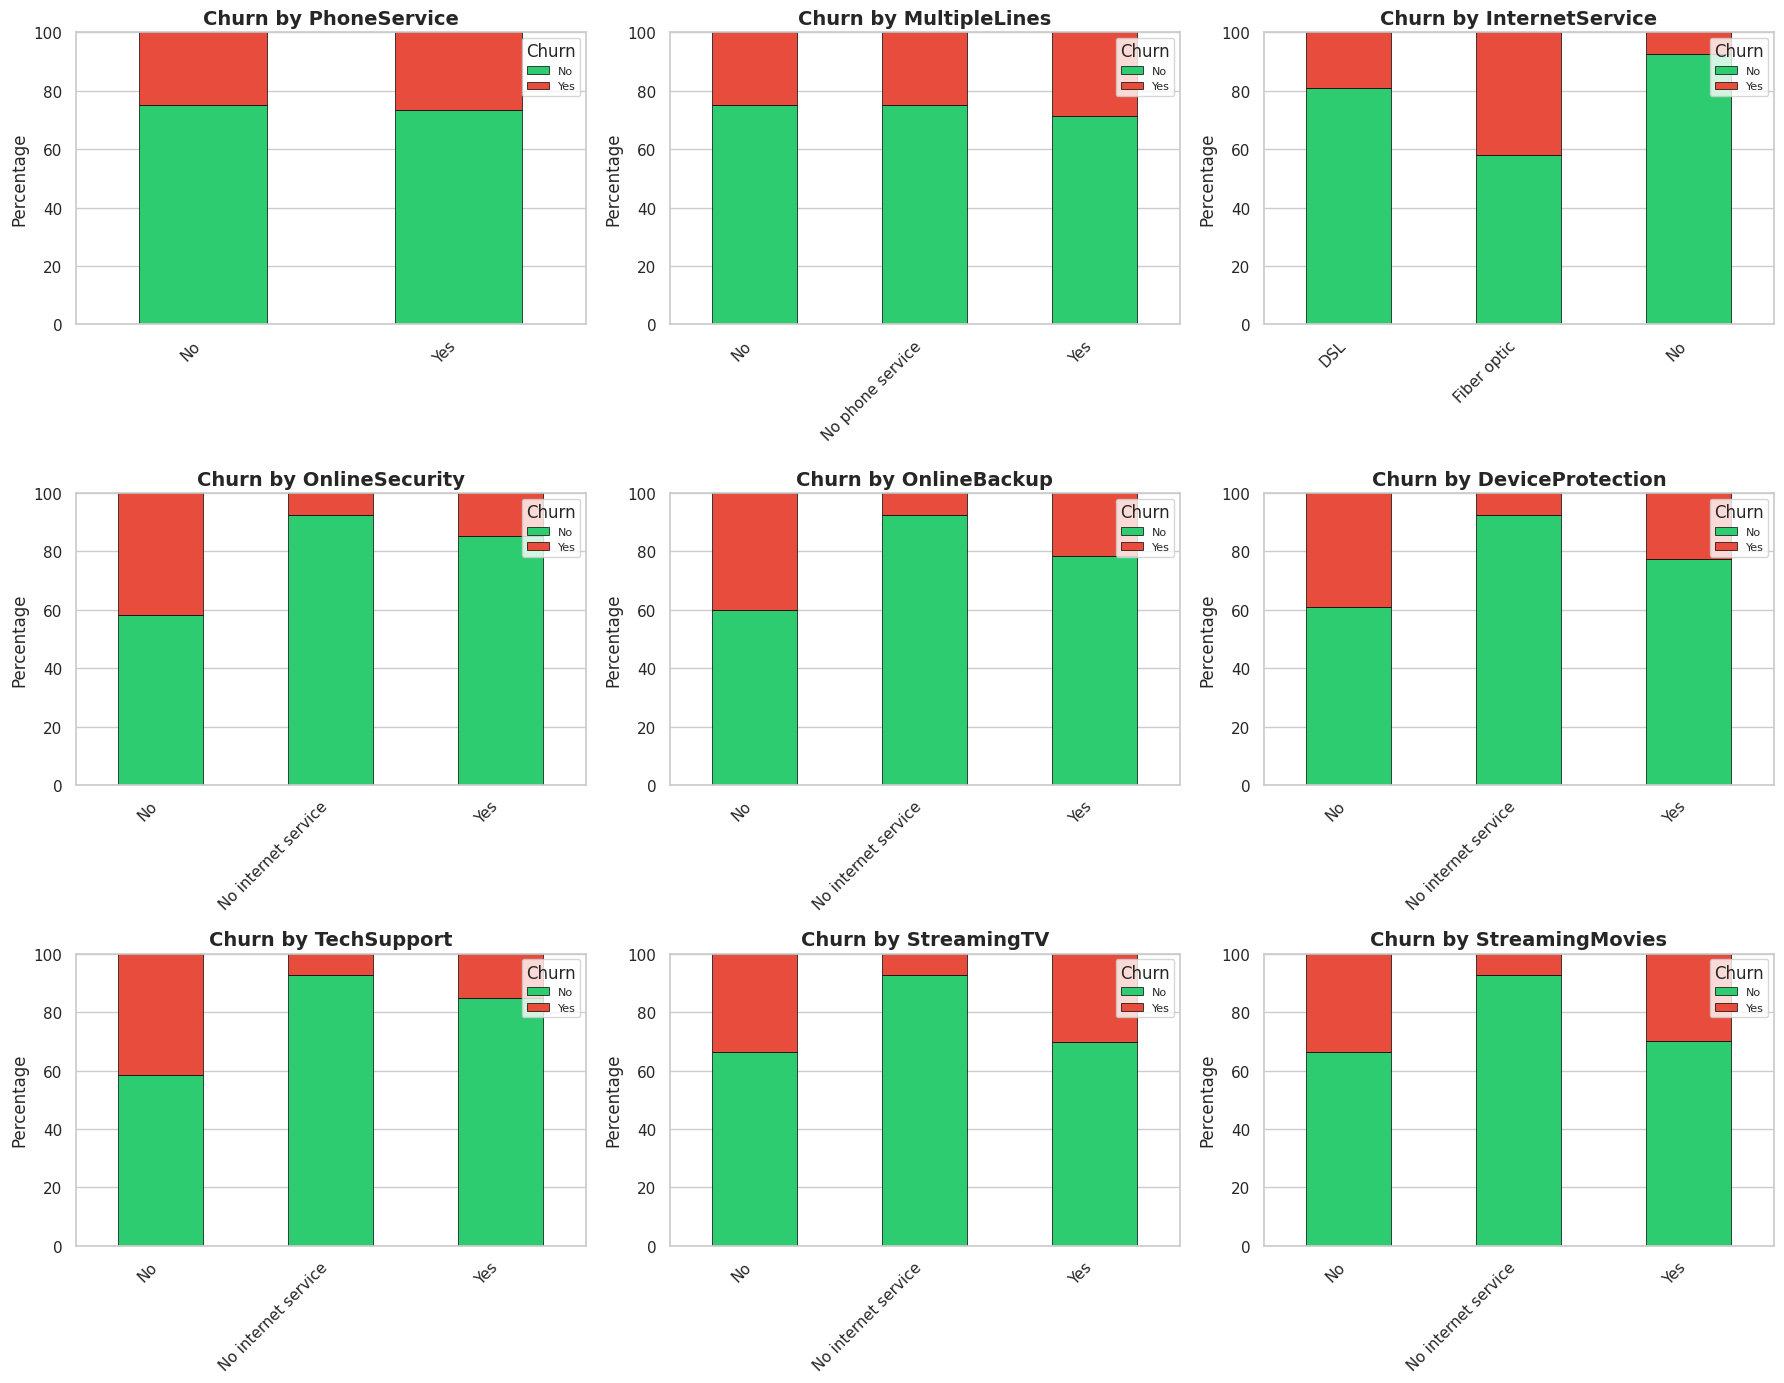

In [36]:
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'Churn by {col}', fontweight='bold')
    axes[i].set_ylabel('Percentage')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].legend(title='Churn', loc='upper right', fontsize=8)
    axes[i].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../notebooks/figures/services_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# The big one: Internet Service churn rates
print("--- Internet Service ---")
for svc_type in df['InternetService'].unique():
    subset = df[df['InternetService'] == svc_type]
    rate = (subset['Churn'] == 'Yes').mean() * 100
    print(f"  {svc_type}: {rate:.1f}% churn ({len(subset):,} customers)")

--- Internet Service ---
  DSL: 19.0% churn (2,421 customers)
  Fiber optic: 41.9% churn (3,096 customers)
  No: 7.4% churn (1,526 customers)


**This is one of the most important findings in the entire analysis:**

**Fiber optic customers churn at 42%** — more than double the DSL rate (19%) and far above the no-internet rate (7%). This is a massive business signal. Possible explanations:
- Fiber optic is more expensive, and the higher price drives more price-sensitive customers away
- Fiber optic customers may have higher expectations for service quality
- Competitors may be aggressively targeting fiber customers with better offers

**Protective services reduce churn dramatically.** Customers who subscribe to OnlineSecurity, TechSupport, OnlineBackup, or DeviceProtection all churn at significantly lower rates (~15%) compared to those without these services (~42% for security-less customers on internet plans). These add-ons create stickiness.

**Streaming services are neutral.** StreamingTV and StreamingMovies show roughly similar churn rates regardless of subscription, which suggests they do not strongly influence the decision to leave.

### 6.3 Account Features: Contract, Billing, Payment

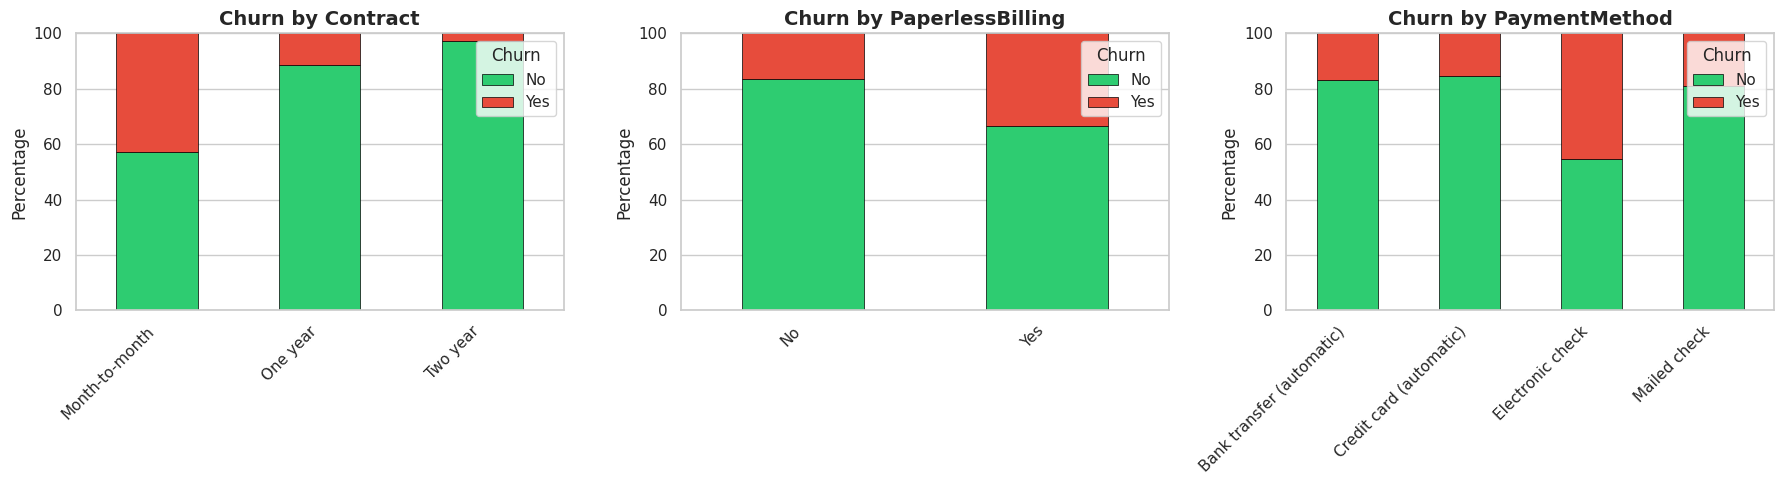

In [38]:
account_cols = ['Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(account_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'Churn by {col}', fontweight='bold')
    axes[i].set_ylabel('Percentage')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].legend(title='Churn', loc='upper right')
    axes[i].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../notebooks/figures/account_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Exact churn rates
for col in account_cols:
    print(f"\n--- {col} ---")
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
    print(churn_rate.to_string())


--- Contract ---
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8

--- PaperlessBilling ---
PaperlessBilling
No     16.3
Yes    33.6

--- PaymentMethod ---
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1


**Key Findings:**

1. **Contract type is the strongest categorical predictor.** Month-to-month contracts have a 43% churn rate, compared to 11% for one-year and just 3% for two-year contracts. This makes intuitive sense — customers locked into longer contracts simply cannot leave as easily, and those who choose longer contracts are already signalling commitment.

2. **Paperless billing correlates with higher churn** (34% vs 16%). This likely reflects customer profiles rather than causation — tech-savvy, younger customers who opt for paperless billing may also be more willing to shop around and switch providers.

3. **Electronic check users churn at 45%**, far above the ~15–18% for other payment methods. Automatic payments (bank transfer, credit card) create inertia — cancelling requires actively changing a payment setup. Electronic check customers may also be less financially committed to the service.

## 7. Correlation Analysis

To see how all features relate to each other and to churn, I need to encode the categorical variables temporarily. This is just for visualisation here — the actual preprocessing for modelling will be more careful and happen in Phase 2.

Note: you may need to restart the kernel to use updated packages.


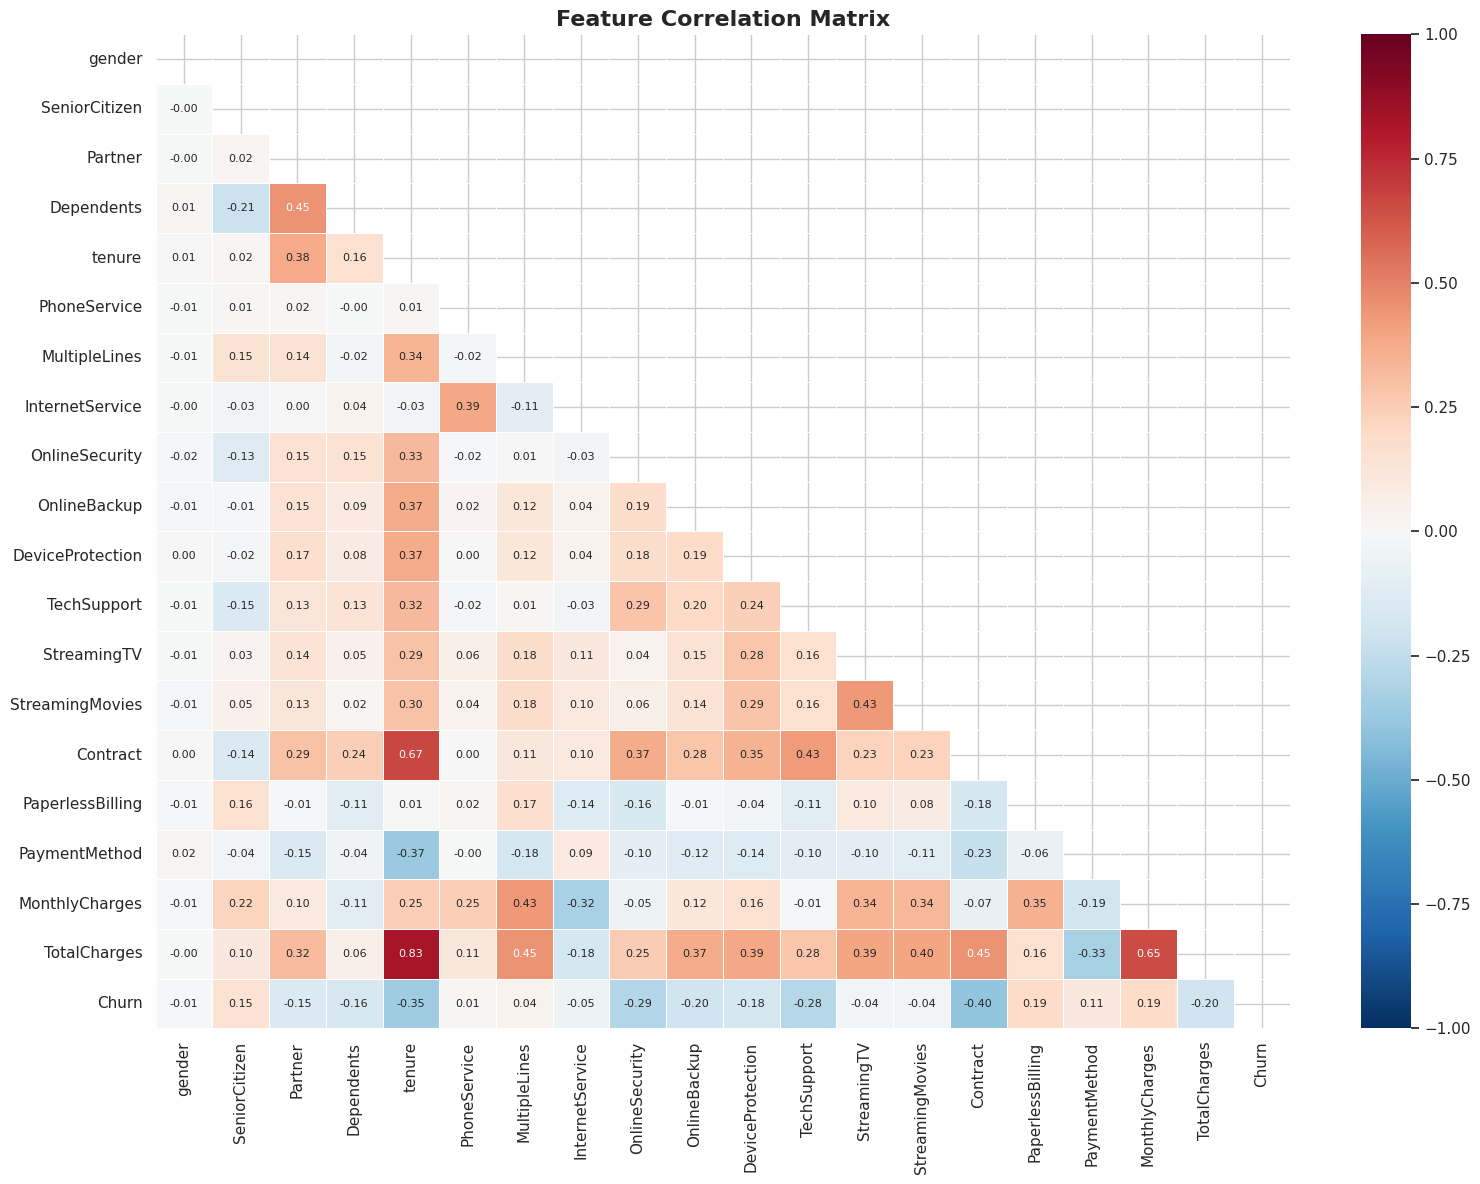

In [41]:
%pip install scikit-learn

# Create a temporary encoded copy for correlation analysis
df_encoded = df.copy()
df_encoded.drop('customerID', axis=1, inplace=True)

# Encode Churn as 1/0
df_encoded['Churn'] = (df_encoded['Churn'] == 'Yes').astype(int)

# Label-encode all remaining object columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Compute correlation matrix
corr_matrix = df_encoded.corr()

# Plot
fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig('../notebooks/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# Top correlations with Churn, sorted by absolute value
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print("Correlations with Churn (sorted by strength):\n")
print(churn_corr.round(3).to_string())

Correlations with Churn (sorted by strength):

Contract           -0.397
tenure             -0.352
OnlineSecurity     -0.289
TechSupport        -0.282
TotalCharges       -0.198
OnlineBackup       -0.196
MonthlyCharges      0.193
PaperlessBilling    0.192
DeviceProtection   -0.178
Dependents         -0.164
SeniorCitizen       0.151
Partner            -0.150
PaymentMethod       0.107
InternetService    -0.047
StreamingMovies    -0.038
MultipleLines       0.038
StreamingTV        -0.037
PhoneService        0.012
gender             -0.009


### Correlation Insights

**Strongest positive correlations with churn** (higher value → more churn):
- Month-to-month contract
- No online security / no tech support
- Fiber optic internet
- Electronic check payment
- Paperless billing
- Higher monthly charges

**Strongest negative correlations with churn** (higher value → less churn):
- Longer tenure
- Two-year contract
- Having online security, tech support, device protection
- Higher total charges (proxy for longer tenure)

**Notable inter-feature correlations:**
- `tenure` and `TotalCharges` are highly correlated (~0.83), which makes sense since total charges accumulate over time. We may want to keep only one of these or be aware of multicollinearity.
- Several service add-ons (OnlineSecurity, TechSupport, DeviceProtection, OnlineBackup) are correlated with each other — customers who buy one tend to buy others.

## 8. Tenure Deep Dive

Tenure stood out as one of the strongest predictors. Let's look at it more closely by binning it into groups and examining churn rates across the customer lifecycle.

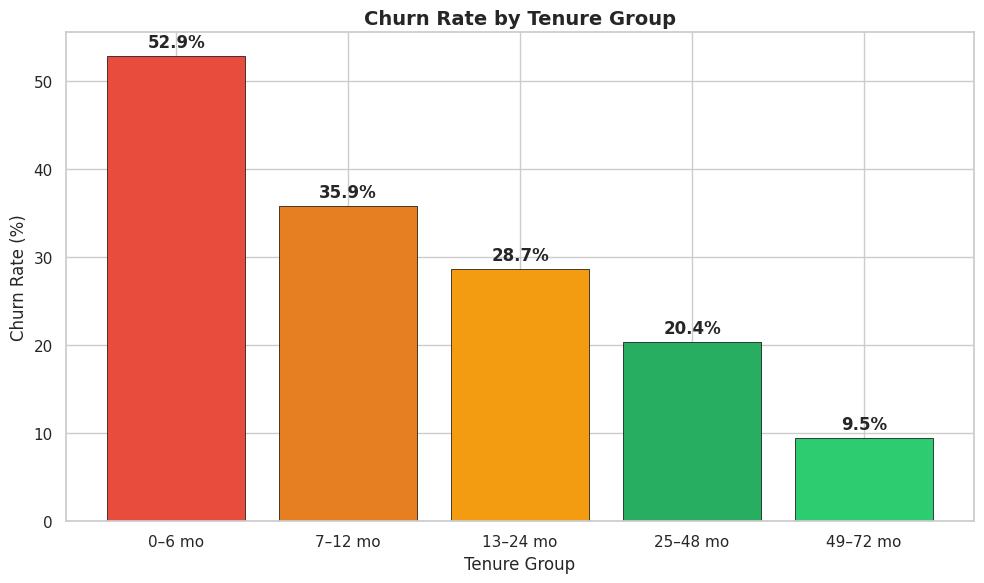

In [43]:
# Bin tenure into meaningful groups
tenure_bins = [0, 6, 12, 24, 48, 72]
tenure_labels = ['0–6 mo', '7–12 mo', '13–24 mo', '25–48 mo', '49–72 mo']
df['tenure_group'] = pd.cut(df['tenure'], bins=tenure_bins, labels=tenure_labels, include_lowest=True)

# Churn rate by tenure group
tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
tenure_churn.columns = ['Tenure Group', 'Churn Rate (%)']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(tenure_churn['Tenure Group'], tenure_churn['Churn Rate (%)'],
              color=['#e74c3c', '#e67e22', '#f39c12', '#27ae60', '#2ecc71'],
              edgecolor='black', linewidth=0.5)
ax.set_title('Churn Rate by Tenure Group', fontweight='bold', fontsize=14)
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Tenure Group')

for bar, val in zip(bars, tenure_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../notebooks/figures/tenure_churn_rate.png', dpi=150, bbox_inches='tight')
plt.show()

# Clean up temporary column
df.drop('tenure_group', axis=1, inplace=True)

**The pattern is crystal clear:** churn drops dramatically as tenure increases. Customers in their first 6 months are the highest risk group. Once a customer survives past 2 years, they are very unlikely to leave.

This tells the business exactly when to intervene: **the first 6–12 months are the danger zone.** Retention offers, check-ins, and onboarding improvements should be targeted at new customers.

## 9. EDA Summary and Next Steps

### What I Learned About This Data

**Data Quality:**
- Dataset is clean overall — 7,043 customers, no duplicates
- Only issue was 11 blank TotalCharges values (new customers with tenure=0), fixed by filling with 0
- TotalCharges needed type conversion from string to float

**Class Imbalance:**
- 26.5% churn rate (1,869 churners vs 5,174 non-churners)
- Accuracy is not a reliable metric — will use F1 Score and ROC-AUC instead

**Strongest Churn Predictors (what the model should focus on):**

| Feature | Why It Matters |
|---------|---------------|
| **Contract type** | Month-to-month → 43% churn; Two-year → 3% churn |
| **Tenure** | First 6 months → ~50% churn; 49–72 months → ~7% churn |
| **Internet service** | Fiber optic → 42% churn; DSL → 19% |
| **Online Security / Tech Support** | Not having these → ~42% churn; having them → ~15% |
| **Payment method** | Electronic check → 45% churn; automatic methods → ~15% |
| **Monthly charges** | Higher charges correlate with higher churn |

**Features with weak/no predictive power:**
- Gender (nearly identical churn rates)
- PhoneService alone (minimal difference)

### Decisions for Phase 2 (Preprocessing)
1. **Drop `customerID`** — it is an identifier, not a feature
2. **Encode categoricals** — use One-Hot Encoding for multi-category features (Contract, InternetService, PaymentMethod) and simple binary mapping for Yes/No columns
3. **Scale numerical features** — StandardScaler on tenure, MonthlyCharges, TotalCharges
4. **Consider the tenure-TotalCharges correlation** — monitor for multicollinearity
5. **Use stratified train/test split** — to preserve the 26.5/73.5 class ratio in both sets
6. **Address class imbalance** in Phase 3 — experiment with class weights in the models

---

*Phase 1 complete. Moving to Phase 2: Data Preprocessing.*